In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Mini Project: To predict Movie vote_count based on popularity and vote_average

In [43]:
df=pd.read_csv("Documents/data science practice/ML_PROJECT/movies.csv")
df

,Unnamed: 0,id,title,overview,release_date,popularity,vote_average,vote_count
0,0,278,The Shawshank Redemption,Imprisoned in the 1940s for the double murder ...,23/09/1994,158.024,8.700,27814
1,1,238,The Godfather,"Spanning the years 1945 to 1955, a chronicle o...",14/03/1972,187.671,8.689,21113
2,2,240,The Godfather Part II,In the continuing saga of the Corleone crime f...,20/12/1974,89.640,8.570,12745
3,3,424,Schindler's List,The true story of how businessman Oskar Schind...,15/12/1993,90.413,8.567,16190
4,4,389,12 Angry Men,The defense and the prosecution have rested an...,10/04/1957,61.573,8.548,8933
...,...,...,...,...,...,...,...,...
9995,9995,510452,All Inclusive,A man goes on an all-inclusive vacation to the...,13/02/2019,5.187,3.900,307
9996,9996,205321,Sharknado,"A freak hurricane hits Los Angeles, causing ma...",11/07/2013,9.558,3.918,1586
9997,9997,238930,Brain Drain,Five friends forge their resumes and enroll to...,21/11/2013,6.546,3.900,437
9998,9998,9760,Epic Movie,When the Pevensie siblings each follow their o...,25/01/2007,23.450,3.850,1553


In [45]:
# df.drop('Unnamed: 0', axis=1, inplace=True)
df.drop_duplicates(inplace=True)
df.dropna(inplace=True)
df.reset_index(drop=True, inplace=True)
df

,id,title,overview,release_date,popularity,vote_average,vote_count
0,278,The Shawshank Redemption,Imprisoned in the 1940s for the double murder ...,23/09/1994,158.024,8.700,27814
1,238,The Godfather,"Spanning the years 1945 to 1955, a chronicle o...",14/03/1972,187.671,8.689,21113
2,240,The Godfather Part II,In the continuing saga of the Corleone crime f...,20/12/1974,89.640,8.570,12745
3,424,Schindler's List,The true story of how businessman Oskar Schind...,15/12/1993,90.413,8.567,16190
4,389,12 Angry Men,The defense and the prosecution have rested an...,10/04/1957,61.573,8.548,8933
...,...,...,...,...,...,...,...
9993,510452,All Inclusive,A man goes on an all-inclusive vacation to the...,13/02/2019,5.187,3.900,307
9994,205321,Sharknado,"A freak hurricane hits Los Angeles, causing ma...",11/07/2013,9.558,3.918,1586
9995,238930,Brain Drain,Five friends forge their resumes and enroll to...,21/11/2013,6.546,3.900,437
9996,9760,Epic Movie,When the Pevensie siblings each follow their o...,25/01/2007,23.450,3.850,1553


In [46]:
df.head()

,id,title,overview,release_date,popularity,vote_average,vote_count
0,278,The Shawshank Redemption,Imprisoned in the 1940s for the double murder ...,23/09/1994,158.024,8.700,27814
1,238,The Godfather,"Spanning the years 1945 to 1955, a chronicle o...",14/03/1972,187.671,8.689,21113
2,240,The Godfather Part II,In the continuing saga of the Corleone crime f...,20/12/1974,89.640,8.570,12745
3,424,Schindler's List,The true story of how businessman Oskar Schind...,15/12/1993,90.413,8.567,16190
4,389,12 Angry Men,The defense and the prosecution have rested an...,10/04/1957,61.573,8.548,8933


In [47]:
df.tail()

,id,title,overview,release_date,popularity,vote_average,vote_count
9993,510452,All Inclusive,A man goes on an all-inclusive vacation to the...,13/02/2019,5.187,3.900,307
9994,205321,Sharknado,"A freak hurricane hits Los Angeles, causing ma...",11/07/2013,9.558,3.918,1586
9995,238930,Brain Drain,Five friends forge their resumes and enroll to...,21/11/2013,6.546,3.900,437
9996,9760,Epic Movie,When the Pevensie siblings each follow their o...,25/01/2007,23.450,3.850,1553
9997,94365,The Human Centipede 3 (Final Sequence),Taking inspiration from The Human Centipede fi...,22/05/2015,24.825,3.700,773


In [48]:
df.describe()

,id,popularity,vote_average,vote_count
count,9.998000e+03,9998.000000,9998.000000,9998.000000
mean,2.036226e+05,24.124012,6.631629,1987.907181
std,2.691817e+05,59.639727,0.772538,3165.795650
min,2.000000e+00,0.017000,3.700000,300.000000
25%,1.021050e+04,10.592000,6.100000,465.000000
50%,3.840250e+04,15.060000,6.661000,841.000000
75%,3.719548e+05,24.261500,7.200000,1962.750000
max,1.261501e+06,2415.786000,8.700000,37122.000000


In [49]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9998 entries, 0 to 9997
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   id            9998 non-null   int64  
 1   title         9998 non-null   object 
 2   overview      9998 non-null   object 
 3   release_date  9998 non-null   object 
 4   popularity    9998 non-null   float64
 5   vote_average  9998 non-null   float64
 6   vote_count    9998 non-null   int64  
dtypes: float64(2), int64(2), object(3)
memory usage: 546.9+ KB


In [50]:
df.isnull().sum()

id              0
title           0
overview        0
release_date    0
popularity      0
vote_average    0
vote_count      0
dtype: int64

In [54]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import r2_score 




In [61]:
# x values are : movie name,popularity and vote_average


le_title=LabelEncoder()

x=df[['popularity', 'vote_average']]
y=df['vote_count']

model=RandomForestRegressor(n_estimators=150,random_state=42)


model.fit(x,y)

y_pred=model.predict(x)

r2=r2_score(y,y_pred)
 
# new data
movie=input("Enter Movie Name:")
popul=float(input("Enter Popularity rate:"))
vote_avg=float(input("Enter Vote Average of this movie"))

# prediction
pred=model.predict([[popul,vote_avg]])
print("Vote Average: ",int(pred[0]))

print("R2 score:",r2*100,"%")




Enter Movie Name: Veera
Enter Popularity rate: 8.79
Enter Vote Average of this movie 165.98


Vote Average:  772
R2 score: 92.63753165846593 %


C:\Users\ELCOT\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


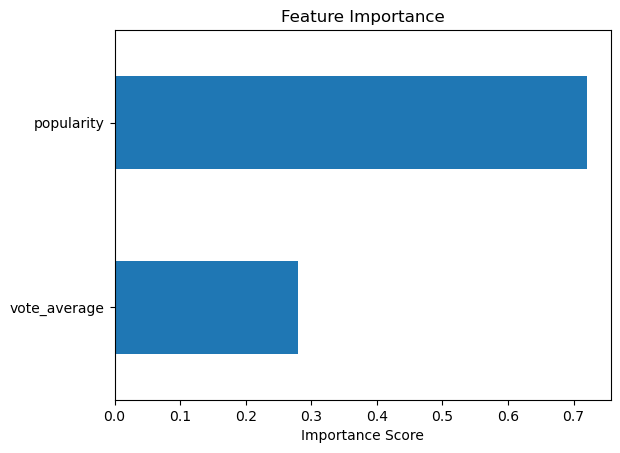

In [62]:
# Feature impotance graph to find which feature contributes most
importance = pd.Series(
    model.feature_importances_,
    index=x.columns
)

importance.sort_values().plot(kind='barh')

plt.title("Feature Importance")
plt.xlabel("Importance Score")
plt.show()

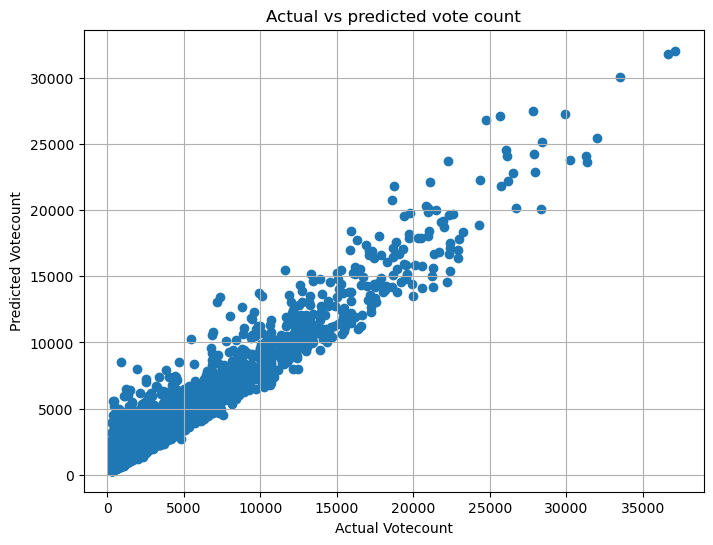

In [66]:
# let plot actual vs predicted votecount using scatterplot
plt.figure(figsize=(8,6))
plt.scatter(y,y_pred)
plt.xlabel("Actual Votecount")
plt.ylabel("Predicted Votecount")
plt.title("Actual vs predicted vote count")
plt.grid()
plt.show()